# ДЗ №6
### *виконала студентка групи ФБ-33 Журавльова Марія* ###

Нагадаю, що мій набір даних - TMDB 10000 Movies Dataset (https://www.kaggle.com/datasets/i0xc0d3x00000/tmdb-10000-movies-dataset)

**Опис колонок:**

- title - назва фільму;
- overview - опис сюжету фільму;
- release_date - оригінальна дата випуску;
- vote_average - середній рейтинг фільму;
- vote_count - кількість отриманих голосів;
- original_language - мова зйомки;
- popularity - індекс популярності.

**Завдання:**
- ***зробити коробчасту діаграму, скрипковий графік, гістограму, графік густини, контурний графік. Для будь-яких атрибутів.***

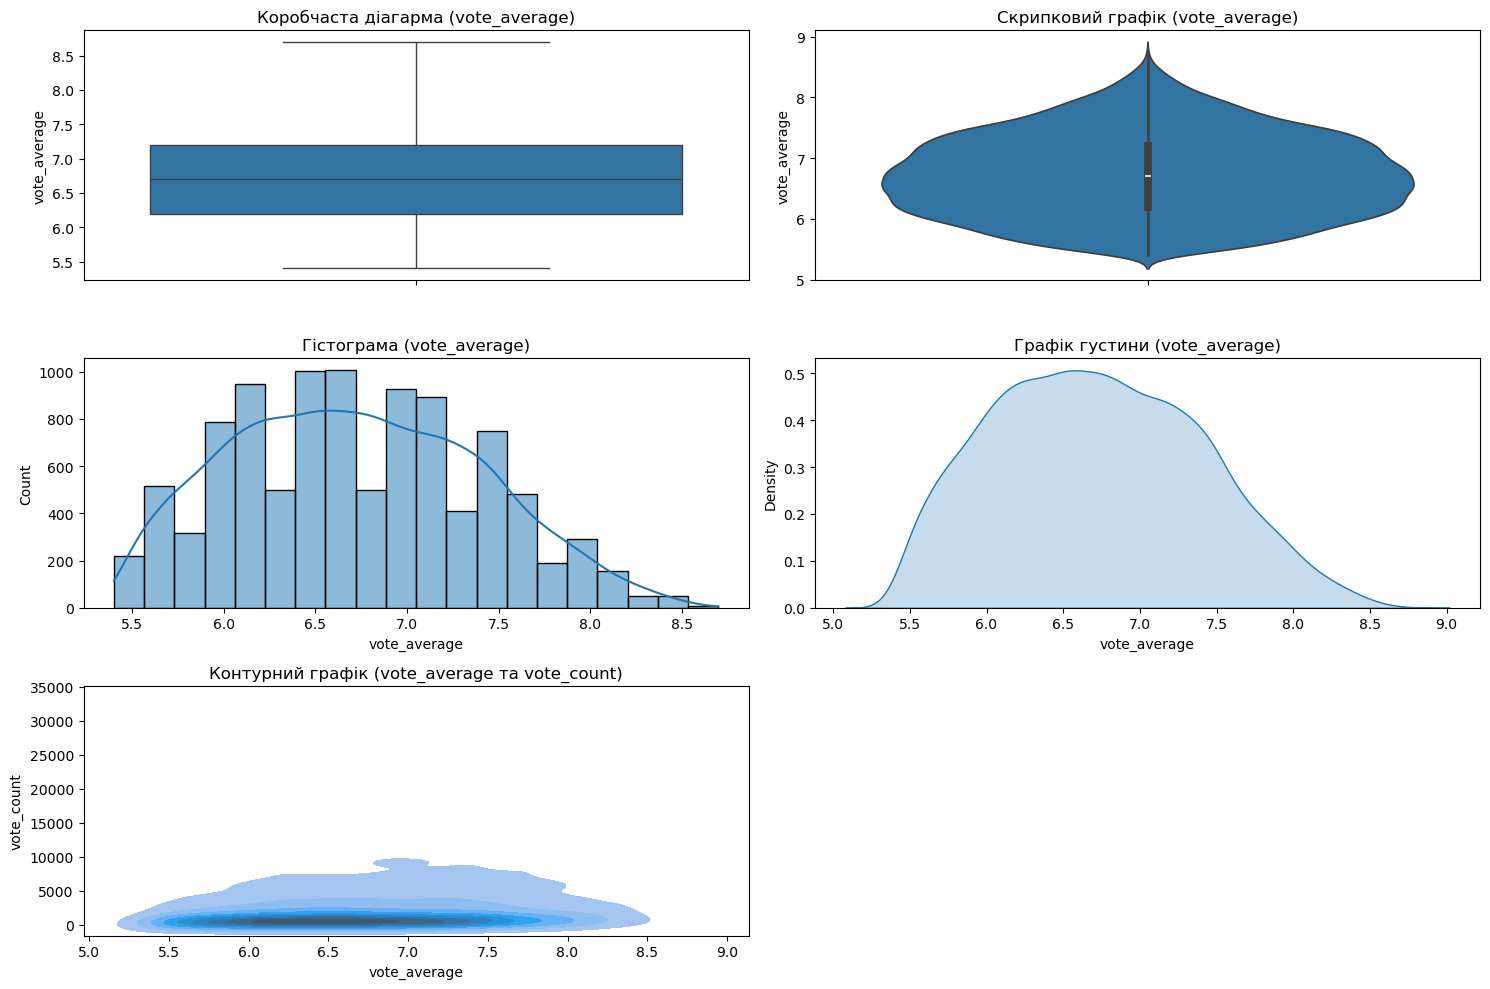

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних
df = pd.read_csv(r"C:\Users\User\OneDrive\Desktop\university\МТАД\movies-tmdb-10000.csv")

plt.figure(figsize=(15,10))

# Коробчаста діаграма
plt.subplot(3, 2, 1)
sns.boxplot(y=df['vote_average'])
plt.title('Коробчаста діагарма (vote_average)')

# Скрипковий графік
plt.subplot(3, 2, 2)
sns.violinplot(y=df['vote_average'])
plt.title('Скрипковий графік (vote_average)')

# Гістограма
plt.subplot(3, 2, 3)
sns.histplot(df['vote_average'], kde=True, bins=20)
plt.title('Гістограма (vote_average)')

# Графік густини
plt.subplot(3, 2, 4)
sns.kdeplot(x=df['vote_average'], fill=True)
plt.title('Графік густини (vote_average)')

# Контурний графік
plt.subplot(3, 2, 5)
sns.kdeplot(x=df['vote_average'], y=df['vote_count'], fill=True)
plt.title('Контурний графік (vote_average та vote_count)')
plt.tight_layout()
plt.show()

- ***побудувати коефіцієнти кореляцій для 2 атрибутів. побудувати кореляційну матицю.***

Коефіцієнт кореляції між vote_average та vote_count: 0.2596


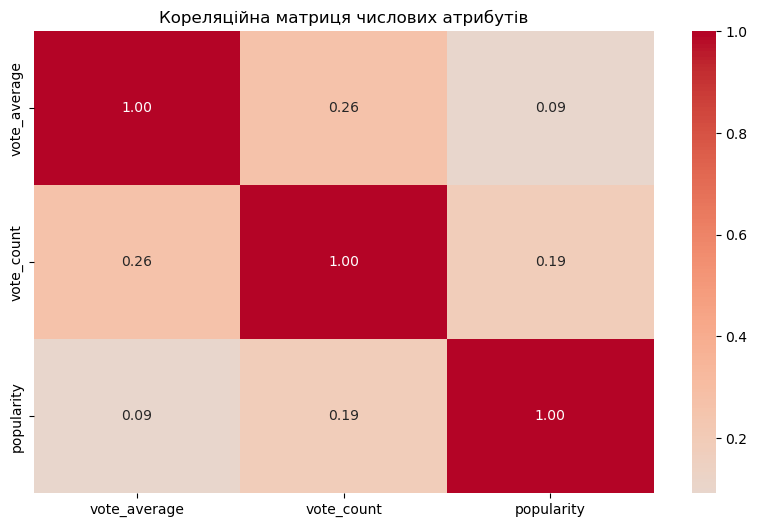

In [79]:
from scipy import stats

# Коєфіцієнт кореляції між двома атрибутами
coef = df['vote_average'].corr(df['vote_count'])
print(f"Коефіцієнт кореляції між vote_average та vote_count: {coef:.4f}")

# Кореляційна матриця для кількох числових атрибутів
num_df = df[['vote_average', 'vote_count', 'popularity']].copy()
matrix = num_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Кореляційна матриця числових атрибутів')
plt.show()

Бачимо слабку позитивну кореляцію між vote_average та vout_count. Це свідчить, що велика кількість голосів не гарантує високої якості фільму. Також у кореляційній матриці можна побачити незалежність якості від масовості. Оскільки між vote_average та vote_count слабка кореляція, а між vote_average та popularity вона ще слабша, це підтверджує, що середній рейтинг фільму значною мірою незалежний від його поточною масовості чи хайпу. Фільми з високим рейтингом не обов'язково є найбільш оцінюваними чи найбільш популярними.

- ***за допомогою методу головних компонент визначити основні компоненти та залежні від них. спропувати інтерпретувати нові атрибути.***

 Компонента 1: 0.4559 (45.59% дисперсій)
 Компонента 2: 0.3048 (30.48% дисперсій)
 Компонента 3: 0.2393 (23.93% дисперсій)


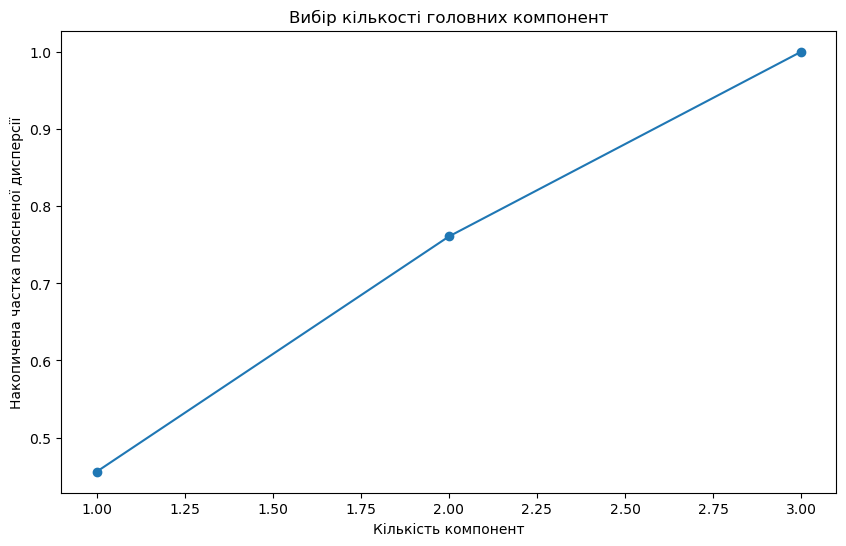

     vote_average  vote_count  popularity
PC1      0.582081   -0.561410   -0.588218
PC2      0.656409   -0.102519    0.747407
PC3      0.479906    0.821163   -0.308840


In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

x = StandardScaler().fit_transform(num_df)

# n_components=3 зберігає 100% дисперсії вихідних даних
pca = PCA(n_components=3)
principal_components = pca.fit_transform(x)

# Пояснена дисперсія
explained_variance = pca.explained_variance_ratio_
for i, var in enumerate(explained_variance, start=1):
    print(f" Компонента {i}: {var:.4f} ({var*100:.2f}% дисперсій)")

# DataFrame з головними компонентами
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])

plt.figure(figsize=(10,6))
plt.plot(range(1, 4), explained_variance.cumsum(), marker='o')
plt.xlabel('Кількість компонент')
plt.ylabel('Накопичена частка поясненої дисперсії')
plt.title('Вибір кількості головних компонент')
plt.show()

# Визначення залежності
loadings = pd.DataFrame(pca.components_.T, columns=num_df.columns, index=['PC1', 'PC2', 'PC3'])
print(loadings)

Отже:
- PC1: цю компоненту можна визначити як якісні, але невідомі фільми.
- PC2: якісні та популярні фільми.
- PC3: культові фільми з великою кількістю голосів.

- ***розрахувати моду та стандартну похибку.***

In [81]:
import numpy as np

mode_vote_average = df['vote_average'].mode()[0]
mode_vote_count = df['vote_count'].mode()[0]
mode_popularity = df['popularity'].mode()[0]

print(f"Мода (vote_average): {mode_vote_average}")
print(f"Мода (vote_count): {mode_vote_count}")
print(f"Мода (popularity): {mode_popularity}")

se_vote_average = df['vote_average'].std() / np.sqrt(len(df))
se_vote_count = df['vote_count'].std() / np.sqrt(len(df))
se_popularity = df['popularity'].std() / np.sqrt(len(df))

print(f"\nСтандартна похибка (vote_average): {se_vote_average:.4f}")
print(f"Стандартна похибка (vote_count): {se_vote_count:.4f}")
print(f"Стандартна похибка (popularity): {se_popularity:.4f}")

Мода (vote_average): 6.5
Мода (vote_count): 202
Мода (popularity): 0.6

Стандартна похибка (vote_average): 0.0068
Стандартна похибка (vote_count): 27.8653
Стандартна похибка (popularity): 0.7133


Можна побачити, що:
- найтиповіша середня оцінка - 6.5, а стандартна похибка мала, що свідчить про стабільність середньої оцінки фільмів.
- найчастіше фільми мають 202 голлосів, проте похибка дуже велика, що свідчить про сильну варіацью даних (є як дуже популярні фільми, так і маловідомі).
- типова популярність низька, але похибка вказує на сильну нерівномірність.

- ***оцінити на який розподіл схожий розподіл ваших даних, виходячи з вигляду основних розділів з теорії ймовірності. (Біномініальний, Пуасоновський, Геометричний, Рівномірний, Показниковий або Гаусовський розподіли).***

Оцінюю розподіл на основі візуального аналізу гістограми та графіку густини для *vote_average*. Обидва графіки демонструють дзвоноподібну форму, що є основною ознакою Гаусовського (Нормального) розподілу.

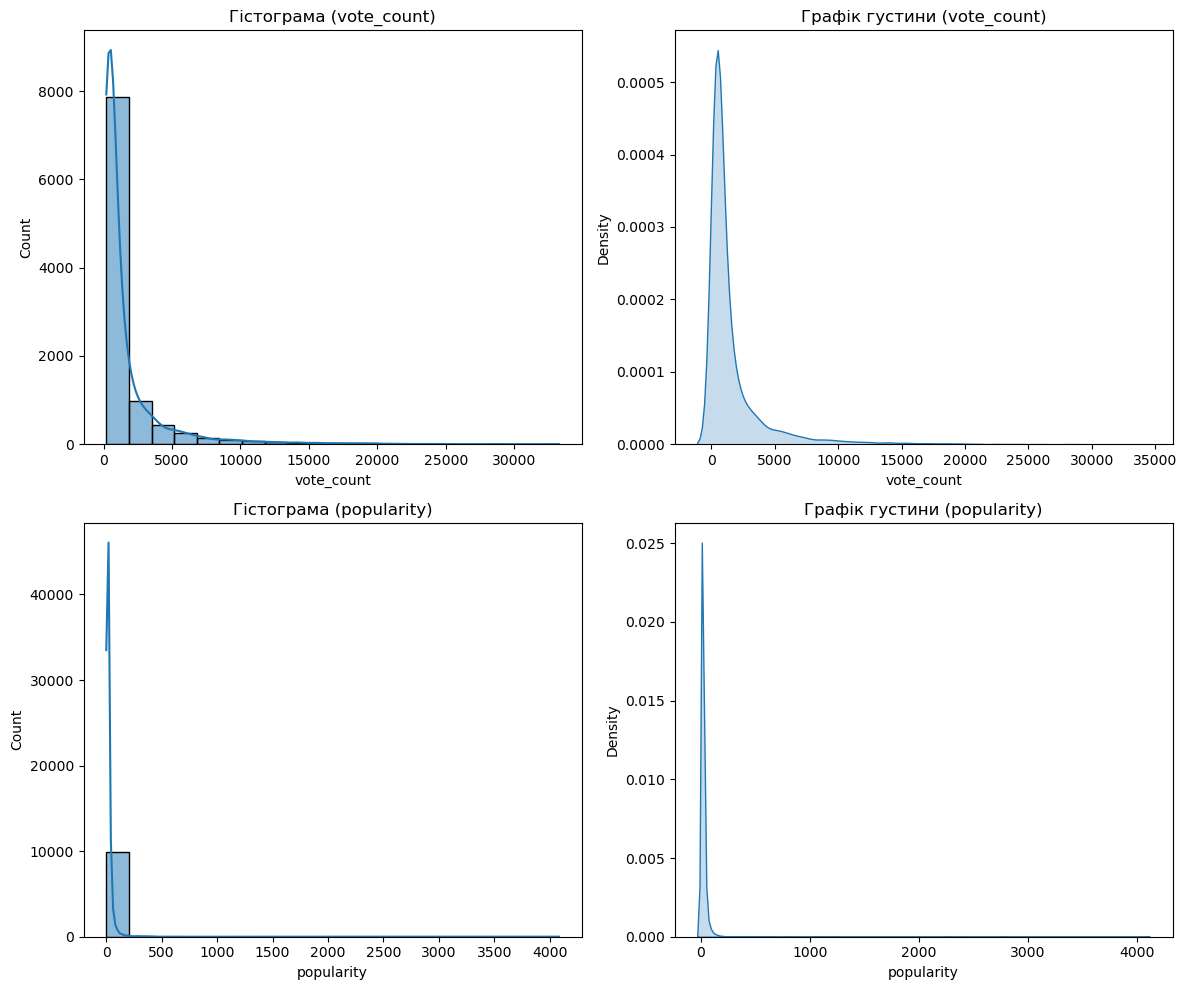

In [82]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['vote_count'], kde=True, bins=20)
plt.title('Гістограма (vote_count)')

plt.subplot(2, 2, 2)
sns.kdeplot(x=df['vote_count'], fill=True)
plt.title('Графік густини (vote_count)')

plt.subplot(2, 2, 3)
sns.histplot(df['popularity'], kde=True, bins=20, log_scale=False)
plt.title('Гістограма (popularity)')

plt.subplot(2, 2, 4)
sns.kdeplot(x=df['popularity'], fill=True)
plt.title('Графік густини (popularity)')

plt.tight_layout()
plt.show()

Тепер оцінюю розподіл на основі візуального аналізу гістограми та графіку густини для *vote_count* та *popularity*. Всі графіки демонструють різкий пік біля нуля, після чого графік стрімко спадає і має довгий правий хвіст. Це вказує на Показниковий розподіл.

- ***зробити бутстрап вибірку для 1000 значень та обрахувати довірчий інтервал.***

In [86]:
from sklearn.utils import resample

n = 1000
bootstrap_means = []
data = df['vote_average']
n_size = len(data)

for _ in range(n):
    sample = resample(data, replace=True, n_samples=n_size)
    bootstrap_means.append(sample.mean())

lower_bound = np.percentile(bootstrap_means, 2.5)
upper_bound = np.percentile(bootstrap_means, 97.5)

print(f"Середнє значення vote_average за бутстрапом: {np.mean(bootstrap_means):.4f}")
print(f"95% довіpчий інтервал для середнього vote_average: ({lower_bound:.4f}, {upper_bound:.4f})")

Середнє значення vote_average за бутстрапом: 6.7231
95% довіpчий інтервал для середнього vote_average: (6.7105, 6.7361)


Можна помітити, що довірчий інтервал є дуже вузьким, що свідчить про високу надійність та точність оцінки середнього значення.